In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math

<div class="alert alert-block alert-success">
<b> </b> 
Convert Head (kJ/kg) vs Flow (ACT_m3/hr) to Pout (barA) vs Flow (ACT_m3/hr)
</div>

In [2]:
#----------------------------------------------------------------------------
#          INPUT-26KA601-Reinjection Compressor Stage-1
#----------------------------------------------------------------------------

head_values_list = [
    [105.42, 102.97, 100.52, 98.07, 93.16, 88.26, 83.36, 78.45],  
    [120.13, 117.68, 115.23, 112.78, 110.32, 107.87, 102.97, 98.07, 88.26],
    [134.84, 132.39, 129.94, 127.49, 122.58, 117.68, 112.78, 107.87, 98.07], 
    [150.04, 149.55, 147.10, 144.65, 142.20, 137.29, 132.39, 122.58, 117.68],
    [166.71, 164.26, 161.81, 156.91, 152.00, 147.10, 142.20, 132.39, 122.58],
    [182.4, 181.91, 181.42, 176.52, 171.62, 166.71, 152.00, 142.20, 127.49]   
]

flow_values_list = [     
    [3300.0, 3800.0, 4200.0, 4500.0, 4900.0, 5200.0, 5500.0, 5700.0],
    [3500.0, 4000.0, 4400.0, 4700.0, 5000.0, 5200.0, 5500.0, 5800.0, 6200.0],
    [3699.9, 4400.0, 4800.0, 5100.0, 5550.0, 5900.0, 6150.0, 6400.0, 6700.0],
    [4100.0, 4500.0, 5000.0, 5300.0, 5600.0, 6000.0, 6300.0, 6800.0, 7250.0],
    [4550.0, 5200.0, 5600.0, 6100.0, 6500.0, 6800.0, 7000.0, 7399.9, 7650.0],
    [5100.0, 5300.0, 5500.0, 6400.0, 6800.0, 7100.0, 7700.0, 8000.0, 8200.0]    
]

rpm_values=[7432, 7897, 8361, 8826, 9290, 9755]


#----------INPUT--------------
P_in = 82.999          # Suction Pressure (barA)
T_in = 273 + 27   # Inlet Temperature (K)
gamma = 1.480    # Heat capacity ratio from unisim
M = 22.270
Zave = 0.8038    # suction Z
R = 8.314



#----------Plot adjustmnts--------------------
#plt.title("Comparison: Manufacturer vs. UniSim - 26KA601")
#plt.xlim(2500, 8500)
# xticks = np.arange(2500, 8501, 250)
# plt.xticks(xticks)
# plt.ylim(75, 250)
# yticks = np.arange(75, 251, 25)
# plt.yticks(yticks)
# plt.grid(True)

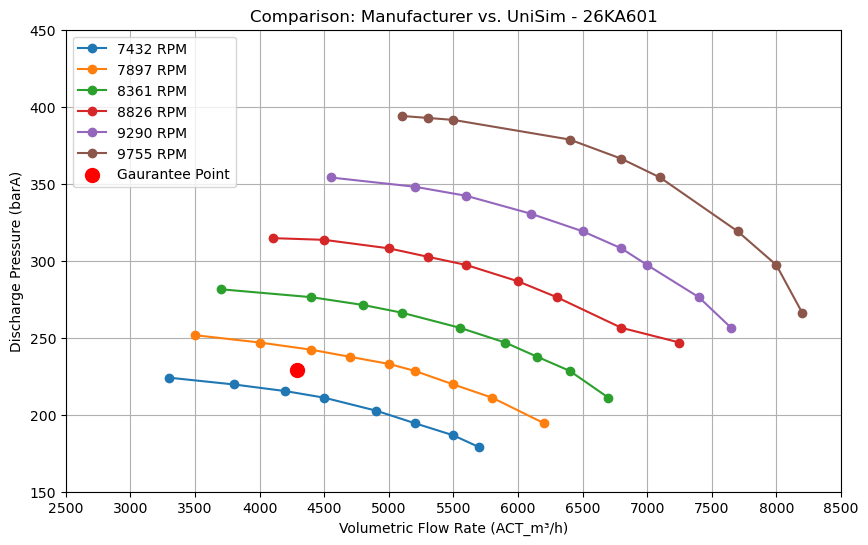

In [3]:
#----------INPUT--------------
#P_in = 171.57          # Suction Pressure (barA)
#T_in = 273 + 40   # Inlet Temperature (K)
#gamma = 1.899   # Heat capacity ratio from unisim
#M = 21.57
#Zave = 0.7202 #(0.8518+0.8717)/2
#R = 8.314

list_of_P_out_values = []
list_of_flow_values = []

    # Compute discharge pressure and flow for each set
for head_values, flow_values in zip(head_values_list, flow_values_list):
    ratio = [1 + ((gamma - 1) / gamma) * H * (M/(Zave * R * T_in)) for H in head_values]
    P_out_values = [(P_in) * (r ** ((gamma / (gamma - 1)))) for r in ratio]    
    flow_value_m3_hr = [F for F in flow_values]
    
# Compute discharge pressure considering efficiency
#for head_values, flow_values, etta_values in zip(head_values_list, flow_values_list, etta_values_list):
#    ratio = [1 + (((gamma - 1) / gamma)* (1/etta)) * H * (M/(Zave * R * T_in)) for H, etta in zip(head_values, etta_values)]
#    P_out_values = [(P_in) * (r ** ((gamma / (gamma - 1)) * etta)) for r, etta in zip(ratio, etta_values)]            
#    flow_value_m3_hr = [F for F in flow_values]
    
    list_of_P_out_values.append(P_out_values)
    list_of_flow_values.append(flow_value_m3_hr)
    
# Identify surge line (start points) and stone wall (end points)
surge_points = [(list_of_flow_values[i][0], list_of_P_out_values[i][0]) for i in range(len(rpm_values))]
stone_wall_points = [(list_of_flow_values[i][-1], list_of_P_out_values[i][-1]) for i in range(len(rpm_values))]
    

# Plot the results
plt.figure(figsize=(10, 6))
plt.xlabel("Volumetric Flow Rate (ACT_m³/h)")
plt.ylabel("Discharge Pressure (barA)")
plt.title("Comparison: Manufacturer vs. UniSim - 26KA601")
plt.xlim(2500, 8500)
xticks = np.arange(2500, 8501, 500)
plt.xticks(xticks)
plt.ylim(150, 450)
yticks = np.arange(150, 451, 50)
plt.yticks(yticks)
plt.grid(True)


for flow_std, P_out, rpm in zip(list_of_flow_values, list_of_P_out_values, rpm_values):
    plt.plot(flow_std, P_out, marker='o', linestyle='-', label=f"{rpm} RPM")
    
    plt.legend()
    
# Add dashed lines for surge and stone wall
surge_x, surge_y = zip(*surge_points)  # Unpack start points
stone_x, stone_y = zip(*stone_wall_points)  # Unpack end points

#plt.plot(surge_x, surge_y, 'r--', linewidth=2, label="Surge Line")  # Dashed red line
#plt.plot(stone_x, stone_y, 'b--', linewidth=2, label="Stone Wall")  # Dashed blue line
    
    
#plt.scatter(4290.00, 228.93, color='red', marker='o', s=100, label="Gaurantee Point")
#plt.legend()

#plt.savefig("26KA601-ReinjectionS1-CaseF HMW.png", dpi=300, bbox_inches='tight')  # Save as PNG


In [4]:
    "


#------------------------------------------------------
#          INPUT-27KA500-Excess Gas Compressor
#------------------------------------------------------

head_values_list = [
    [32.29, 31.19, 28.97, 25.13, 19.89, 16.5], 
    [35.54, 34.95, 32.88, 29.49, 24.62, 18.12],
    [40.78, 40.49, 39.01, 36.21, 31.92, 26.02, 20.41],
    [52.45, 51.78, 49.94, 46.91, 42.48, 36.13, 28.23, 25.72],
    [58.79, 58.57, 57.17, 54.66, 50.97, 45.51, 38.35, 29.05, 28.68],
    [65.59, 65.59, 64.77, 62.78, 59.46, 54.96, 48.75, 40.12, 32.15],
    [72.75, 72.45, 70.90, 68.24, 64.40, 59.09, 51.63, 41.30, 35.98],
    [80.13, 80.13, 79.24, 77.18, 73.78, 69.35, 63.15, 53.85, 41.00, 39.38]
    
]

flow_values_list = [
    [1599.8, 2001.8, 2401.6, 2801.4, 3201.3, 3410.9], 
    [1677.6, 1999.6, 2401.6, 2801.4, 3201.2, 3598.9],
    [1798.6, 1997.5, 2401.6, 2801.4, 3201.3, 3598.9, 3901.5],
    [2049.3, 2401.6, 2801.4, 3203.4, 3598.9, 4003.1, 4400.7, 4508.8],
    [2200.6, 2401.6, 2801.4, 3201.3, 3598.9, 4003.1, 4400.7, 4800.5, 4815.7],
    [2367, 2401.6, 2801.4, 3203.4, 3598.9, 4003.1, 4400.7, 4800.5, 5103.1],
    [2544.3, 2801.4, 3201.3, 3598.93, 4003.1, 4400.7, 4800.5, 5200.4, 5373.3],
    [2721.5, 2801.4, 3203.4, 3598.9, 4003.0, 4400.8, 4800.5, 5200.4, 5602.3, 5645.6]    
]

etta_values_list= [
    [0.7747, 0.8073, 0.8064, 0.7696, 0.6769, 0.6142],
    [0.7734, 0.8014, 0.8098, 0.7887, 0.7243, 0.6045],
    [0.7688, 0.7899, 0.8094, 0.8048, 0.7700, 0.6913, 0.6015],
    [0.7662, 0.7946, 0.8094, 0.8064, 0.7810, 0.7239, 0.6248, 0.5918], 
    [0.7671, 0.7827, 0.8035, 0.8098, 0.8001, 0.7683, 0.7002, 0.5939, 0.5905],
    [0.7662, 0.7696, 0.7954, 0.8081, 0.8077, 0.7933, 0.7531, 0.6748, 0.5905],
    [0.7662, 0.7849, 0.8031, 0.8094, 0.8043, 0.7853, 0.7345, 0.6434, 0.5905],
    [0.7658, 0.7721, 0.7946, 0.8060, 0.8077, 0.8001, 0.7734, 0.7086, 0.6036, 0.5888]
]   

rpm_values=[8200, 8609, 9224, 10453, 11068, 11683, 12298, 12913]


#----------INPUT FROM UNISIM--------------
P_in = 57.4          # Suction Pressure (barA)
T_in = 273 + 26.7   # Inlet Temperature (K)
gamma = 1.503      # Heat capacity ratio from unisim
M = 21.3
Zave = 0.83 #(0.8518+0.8717)/2
R = 8.314

SyntaxError: unterminated string literal (detected at line 1) (221258374.py, line 1)

In [ ]:
#------------------------------------------------------
#          INPUT-26KA601-Reinjection Compressor Stage-1
#------------------------------------------------------

head_values_list = [
    [105.42, 102.97, 100.52, 98.07, 93.16, 88.26, 83.36, 78.45],  
    [120.13, 117.68, 115.23, 112.78, 110.32, 107.87, 102.97, 98.07, 88.26],
    [134.84, 132.39, 129.94, 127.49, 122.58, 117.68, 112.78, 107.87, 98.07], 
    [150.04, 149.55, 147.10, 144.65, 142.20, 137.29, 132.39, 122.58, 117.68],
    [166.71, 164.26, 161.81, 156.91, 152.00, 147.10, 142.20, 132.39, 122.58],
    [182.4, 181.91, 181.42, 176.52, 171.62, 166.71, 152.00, 142.20, 127.49],   
]

flow_values_list = [     
    [3300.0, 3800.0, 4200.0, 4500.0, 4900.0, 5200.0, 5500.0, 5700.0],
    [3500.0, 4000.0, 4400.0, 4700.0, 5000.0, 5200.0, 5500.0, 5800.0, 6200.0],
    [3699.9, 4400.0, 4800.0, 5100.0, 5550.0, 5900.0, 6150.0, 6400.0, 6700.0],
    [4100.0, 4500.0, 5000.0, 5300.0, 5600.0, 6000.0, 6300.0, 6800.0, 7250.0],
    [4550.0, 5200.0, 5600.0, 6100.0, 6500.0, 6800.0, 7000.0, 7399.9, 7650.0],
    [5100.0, 5300.0, 5500.0, 6400.0, 6800.0, 7100.0, 7700.0, 8000.0, 8200.0]    
]

rpm_values=[7432, 7897, 8361, 8826, 9290, 9755]


#----------INPUT FROM UNISIM--------------
P_in = 52          # Suction Pressure (barA)
T_in = 273 + 27   # Inlet Temperature (K)
gamma = 1.480    # Heat capacity ratio from unisim
M = 21.57
Zave = 0.8429 #(0.8518+0.8717)/2
R = 8.314